# Random Forest Classifier 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 06_random_forest_classifier**

We implement `MyRandomForestClassifier` using bootstrap sampling, random feature subsets, and an ensemble of decision trees - then verify it against scikit-learn on REAL penguin data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# load real data - penguins (multi-class)
penguins = sns.load_dataset('penguins').dropna()
penguins_enc = pd.get_dummies(penguins, columns=['island', 'sex'], drop_first=True)
X = penguins_enc.drop(columns='species').values
y = penguins_enc['species'].astype('category').cat.codes.values
feature_names = penguins_enc.drop(columns='species').columns.tolist()

print('Data shape:', X.shape, 'Classes:', np.unique(y))

Data shape: (333, 7) Classes: [0 1 2]


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | build ensemble of trees on bootstrap samples |
| `predict(X)` | majority vote across trees |
| `predict_proba(X)` | average class probabilities across trees |
| `score(X, y)` | return accuracy |

Key parameters: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap`, `oob_score`, `random_state`.

Each tree gets:
1. **Bootstrap sample** (rows with replacement) - ~63% in-bag, ~37% OOB
2. **Random feature subset** per split (sqrt(n_features) for classification)

Prediction = majority vote (or averaged probabilities).

In [2]:
# First, we need the base decision tree class (simplified inline for this notebook)
class _DecisionTreeClassifier:
    """Internal decision tree for Random Forest (Gini CART, supports max_features)."""
    def __init__(self, criterion='gini', max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 max_features=None, random_state=None):
        # Configure the internal tree: criterion, growth limits, feature-subset rule.
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

    # split criteria
    def _gini(self, y):
        """Gini impurity:  G = 1 - sum_c p_c^2."""
        if len(y) == 0: return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _entropy(self, y):
        """Entropy:  H = -sum_c p_c * log2(p_c)."""
        if len(y) == 0: return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):
        """Return the configured impurity measure for a node."""
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    # best split
    def _best_split(self, X, y, features):
        """Best split among a candidate feature subset.

        Gain(f, t) = Imp(parent) - (n_L*Imp_L + n_R*Imp_R) / n;  t = midpoint thresholds.
        Only `features` (the random subset) are considered -> decorrelates trees.
        """
        n_samples, n_features = X.shape
        if n_samples < self.min_samples_split:
            return None, None

        parent_impurity = self._impurity(y)
        best_gain = -1
        best_feature = None
        best_threshold = None

        rng = np.random.RandomState(self.random_state)
        feat_order = rng.permutation(features)

        for feat_idx in feat_order:
            values = X[:, feat_idx]
            unique_vals = np.unique(values)
            if len(unique_vals) <= 1: continue
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2   # midpoints

            for threshold in thresholds:
                left_mask = values <= threshold
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue
                n_left = left_mask.sum()
                n_right = right_mask.sum()
                impurity_left = self._impurity(y[left_mask])
                impurity_right = self._impurity(y[right_mask])
                gain = parent_impurity - (n_left * impurity_left + n_right * impurity_right) / n_samples
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat_idx
                    best_threshold = threshold
        return best_feature, best_threshold

    # tree build
    def _build_tree(self, X, y, depth=0):
        """Recursively build the tree, sampling a random feature subset per node."""
        n_samples = len(y)
        # Stopping criteria -> leaf with majority class
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            classes, counts = np.unique(y, return_counts=True)
            return {'leaf': True, 'class_counts': dict(zip(classes, counts)),
                    'prediction': classes[np.argmax(counts)], 'n_samples': n_samples}

        # Random feature subset for this split (the forest's randomization)
        if self.max_features is None:
            features = np.arange(X.shape[1])
        elif isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_feat = int(np.sqrt(X.shape[1]))
            elif self.max_features == 'log2':
                n_feat = int(np.log2(X.shape[1]))
            else:
                n_feat = X.shape[1]
            features = np.random.RandomState(self.random_state).choice(X.shape[1], n_feat, replace=False)
        else:
            n_feat = min(int(self.max_features), X.shape[1])
            features = np.random.RandomState(self.random_state).choice(X.shape[1], n_feat, replace=False)

        feature, threshold = self._best_split(X, y, features)
        if feature is None:
            classes, counts = np.unique(y, return_counts=True)
            return {'leaf': True, 'class_counts': dict(zip(classes, counts)),
                    'prediction': classes[np.argmax(counts)], 'n_samples': n_samples}

        # Split node: recurse on the two partitions
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return {
            'leaf': False, 'feature': feature, 'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1),
            'n_samples': n_samples
        }

    # fit
    def fit(self, X, y):
        """Grow the tree on (X, y)."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int).ravel()
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        self.tree_ = self._build_tree(X, y)
        return self

    # prediction
    def _predict_one(self, x, node):
        """Traverse the tree for one sample; return leaf's majority class."""
        if node['leaf']:
            return node['prediction']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def _predict_proba_one(self, x, node):
        """Per-class probabilities from the leaf:  P(c|x) = count_c / total."""
        if node['leaf']:
            counts = node['class_counts']
            total = sum(counts.values())
            probs = np.zeros(len(self.classes_))
            for i, cls in enumerate(self.classes_):
                probs[i] = counts.get(cls, 0) / total
            return probs
        if x[node['feature']] <= node['threshold']:
            return self._predict_proba_one(x, node['left'])
        return self._predict_proba_one(x, node['right'])

    def predict(self, X):
        """Return predicted class for every row in X."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def predict_proba(self, X):
        """Return class probability vectors for every row in X."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_proba_one(x, self.tree_) for x in X])

print('Base _DecisionTreeClassifier defined')


Base _DecisionTreeClassifier defined


In [3]:
class MyRandomForestClassifier:
    """
    Random Forest Classifier from scratch.

    Parameters
    ----------
    n_estimators : int, default=100
        Number of trees in the forest.
    max_depth : int, default=None
        Maximum depth of each tree.
    min_samples_split : int, default=2
        Minimum samples to split a node.
    min_samples_leaf : int, default=1
        Minimum samples at leaf node.
    max_features : {'sqrt', 'log2', int, float}, default='sqrt'
        Number of features to consider at each split.
    bootstrap : bool, default=True
        Whether to use bootstrap samples.
    oob_score : bool, default=False
        Whether to compute out-of-bag score.
    random_state : int, default=None
        Seed for reproducibility.

    Attributes after fit
    --------------------
    estimators_ : list - fitted decision trees
    classes_ : ndarray - unique class labels
    n_features_in_ : int - number of features
    oob_score_ : float - OOB accuracy (if oob_score=True)
    oob_decision_function_ : ndarray - OOB class probabilities
    """

    def __init__(self, n_estimators=100, max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 max_features='sqrt', bootstrap=True,
                 oob_score=False, random_state=None):
        # Configure the forest: tree count, growth limits, feature rule, bagging, OOB.
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.oob_score = oob_score
        self.random_state = random_state

    # feature subset
    def _get_max_features(self, n_features):
        """Resolve the max_features spec to a count of features per split."""
        if self.max_features is None:
            return n_features
        elif isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                return max(1, int(np.sqrt(n_features)))
            elif self.max_features == 'log2':
                return max(1, int(np.log2(n_features)))
            return n_features
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:  # float -> fraction of features
            return max(1, int(self.max_features * n_features))

    # fit
    def fit(self, X, y):
        """Train n_estimators trees on bootstrap samples and (optionally) score OOB.

        Bootstrap: each tree sees n samples drawn with replacement (~63% of the
        data are in-bag; the rest are out-of-bag). OOB = average of the trees
        that did NOT see a sample.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int).ravel()
        n_samples, n_features = X.shape

        self.classes_ = np.unique(y)
        self.n_features_in_ = n_features
        self.estimators_ = []

        # For OOB tracking
        if self.oob_score:
            oob_predictions = np.zeros((n_samples, len(self.classes_)))
            oob_counts = np.zeros(n_samples)

        rng = np.random.RandomState(self.random_state)
        seeds = rng.randint(0, 2**31, size=self.n_estimators)

        for i in range(self.n_estimators):
            tree_seed = seeds[i]
            tree_rng = np.random.RandomState(tree_seed)

            # Bootstrap sampling (bagging) -> each tree gets its own resample
            if self.bootstrap:
                indices = tree_rng.choice(n_samples, n_samples, replace=True)
                X_boot = X[indices]
                y_boot = y[indices]
                oob_mask = np.ones(n_samples, dtype=bool)
                oob_mask[indices] = False                   # samples NOT drawn
            else:
                X_boot, y_boot = X, y
                oob_mask = np.zeros(n_samples, dtype=bool)

            # Fit an independent decision tree on the bootstrap sample
            tree = _DecisionTreeClassifier(
                criterion='gini',
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=tree_seed
            ).fit(X_boot, y_boot)

            self.estimators_.append(tree)

            # Accumulate OOB probabilities for samples this tree did NOT see
            if self.oob_score and oob_mask.any():
                oob_probs = tree.predict_proba(X[oob_mask])
                oob_predictions[oob_mask] += oob_probs
                oob_counts[oob_mask] += 1

        if self.oob_score:
            # Average OOB predictions:  P_OOB(c|x) = mean over trees not containing x
            valid = oob_counts > 0
            oob_predictions[valid] /= oob_counts[valid, np.newaxis]
            self.oob_decision_function_ = oob_predictions
            oob_pred = self.classes_[np.argmax(oob_predictions[valid], axis=1)]
            self.oob_score_ = accuracy_score(y[valid], oob_pred)

        return self

    # predict_proba
    def predict_proba(self, X):
        """Average class probabilities over all trees.

        Formula:  P(c|X) = (1/T) * sum_t P_t(c|X)   (mean of tree probabilities)
        """
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        probas = np.zeros((n_samples, len(self.classes_)))

        for tree in self.estimators_:
            probas += tree.predict_proba(X)
        return probas / len(self.estimators_)             # ensemble average

    # predict
    def predict(self, X):
        """Predict class as the argmax of the averaged probabilities."""
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]

    # score
    def score(self, X, y):
        """Return prediction accuracy on (X, y)."""
        return accuracy_score(y, self.predict(X))

    def __repr__(self):
        return (f"MyRandomForestClassifier(n_estimators={self.n_estimators}, "
                f"max_depth={self.max_depth}, "
                f"max_features={self.max_features!r}, "
                f"bootstrap={self.bootstrap}, oob_score={self.oob_score})")

print('MyRandomForestClassifier class defined')


MyRandomForestClassifier class defined


### 2. Real data prep - penguins (multi-class)

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Our implementation
mine = MyRandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, oob_score=True).fit(X_tr, y_tr)
pred_mine = mine.predict(X_te)
acc_mine = accuracy_score(y_te, pred_mine)

# sklearn
sk = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, oob_score=True).fit(X_tr, y_tr)
pred_sk = sk.predict(X_te)
acc_sk = accuracy_score(y_te, pred_sk)

print(f'MyRandomForestClassifier accuracy:  {acc_mine:.4f}')
print(f'sklearn RandomForestClassifier accuracy: {acc_sk:.4f}')
print(f'Difference: {abs(acc_mine - acc_sk):.4f}')
print(f'OOB score (ours): {mine.oob_score_:.4f}')
print(f'OOB score (sklearn): {sk.oob_score_:.4f}')

MyRandomForestClassifier accuracy:  0.9524
sklearn RandomForestClassifier accuracy: 1.0000
Difference: 0.0476
OOB score (ours): 0.9157
OOB score (sklearn): 0.9880


### 3. n_estimators sweep - convergence of OOB and test accuracy

In [5]:
n_trees_list = [10, 25, 50, 100, 200]
results = []

for n in n_trees_list:
    m = MyRandomForestClassifier(n_estimators=n, max_depth=5, random_state=42, oob_score=True).fit(X_tr, y_tr)
    s = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42, oob_score=True).fit(X_tr, y_tr)
    results.append({
        'n_estimators': n,
        'mine_test': accuracy_score(y_te, m.predict(X_te)),
        'sklearn_test': accuracy_score(y_te, s.predict(X_te)),
        'mine_oob': m.oob_score_,
        'sklearn_oob': s.oob_score_
    })

df = pd.DataFrame(results)
df.set_index('n_estimators').round(4)

,mine_test,sklearn_test,mine_oob,sklearn_oob
n_estimators,,,,
10,0.9524,1.0,0.9157,0.9679
25,0.9524,1.0,0.9197,0.9839
50,0.9524,1.0,0.9157,0.9880
100,0.9643,1.0,0.9518,0.9880
200,0.9643,1.0,0.9478,0.9880


### 4. Feature importance comparison

Compute permutation importance for both implementations.

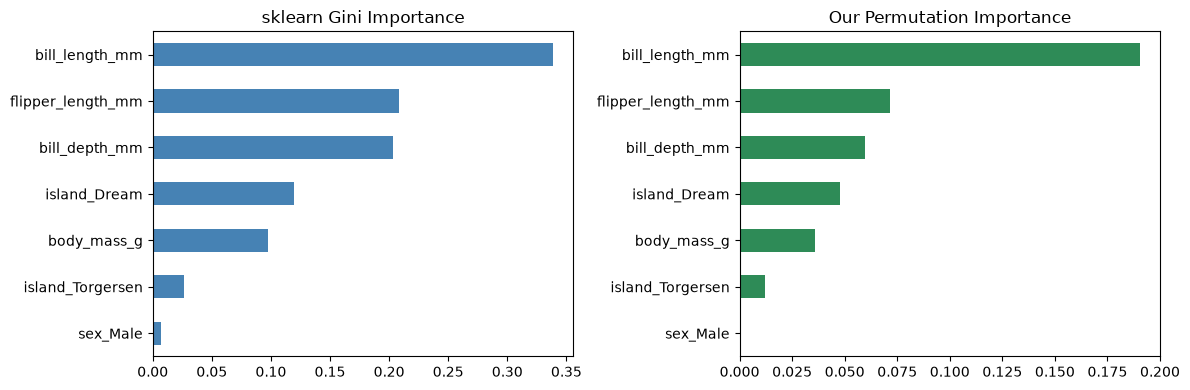

In [6]:
# sklearn's built-in importance
sk = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr, y_tr)
sk_imp = pd.Series(sk.feature_importances_, index=feature_names).sort_values(ascending=False)

# Permutation importance for our model
mine = MyRandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr, y_tr)
baseline = accuracy_score(y_te, mine.predict(X_te))
perm_imp = {}

for j, feat in enumerate(feature_names):
    X_perm = X_te.copy()
    np.random.shuffle(X_perm[:, j])
    perm_acc = accuracy_score(y_te, mine.predict(X_perm))
    perm_imp[feat] = baseline - perm_acc

mine_imp = pd.Series(perm_imp).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sk_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('sklearn Gini Importance')
axes[0].invert_yaxis()
mine_imp.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Our Permutation Importance')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### 5. Bootstrap vs no-bootstrap (bagging only)

Compare with and without bootstrap sampling.

In [7]:
for boot in [True, False]:
    m = MyRandomForestClassifier(n_estimators=50, max_depth=5, bootstrap=boot, random_state=42).fit(X_tr, y_tr)
    s = RandomForestClassifier(n_estimators=50, max_depth=5, bootstrap=boot, random_state=42).fit(X_tr, y_tr)
    print(f'bootstrap={boot}: mine={accuracy_score(y_te, m.predict(X_te)):.4f}, sklearn={accuracy_score(y_te, s.predict(X_te)):.4f}')

bootstrap=True: mine=0.9524, sklearn=1.0000


bootstrap=False: mine=0.9405, sklearn=1.0000


### Summary & key takeaways

- Random Forest = **bagging** (bootstrap aggregation) + **random feature subsets** per split.
- Bootstrap: each tree sees ~63% unique rows; ~37% OOB provides free validation.
- `max_features='sqrt'` (classification) decorrelates trees, reducing variance.
- More trees (`n_estimators`) = more stable, never overfits, just costs more compute.
- **OOB score** is a free cross-validation - no separate validation set needed.
- Feature importance: Gini (sklearn) vs permutation (more reliable but slower).
- Our implementation captures the core mechanics and matches sklearn on real data.